In [16]:
import numpy as np
import healpy as hp
import pickle
from matplotlib.pyplot import *
# from cmblensplus/wrap/
import curvedsky as cs
# from cmblensplus/utils/
import cmb as CMB
import plottools as pl
import maptools
import constant as c
import binning as bn
# others
import local
import tools_multitracer as mass
import tools_delens
import tools_cmb
import warnings
warnings.filterwarnings("ignore")

In [40]:
# define parameters
lbmax  = 4*64     # maximum multipole of alm to be generated
lmax = 2*512
bN = 20
simn = 250
area = 'lbfull'
L = np.linspace(0,lbmax,lbmax+1)
lbmin, lbmax = 2, 190
mb = bn.multipole_binning(bN,lmin=lbmin,lmax=lbmax,lstart=lbmin,spc='')

In [41]:
params = local.analysis()

In [42]:
cobj = tools_cmb.cmb_map()
dobj = tools_delens.filename()

In [43]:
Db = {}
rho = {}
for wmass in dobj.ctypes:
    # read cls
    Ob = np.zeros((simn,bN))
    Rb = np.zeros((simn,bN))
    Lb = np.zeros((simn,bN))
    Xb = np.zeros((simn,bN))
    rho[wmass] = np.zeros((simn,bN))
    Db[wmass] = np.zeros((simn,bN))
    for rlz in range(1,simn+1):
        obb, rbb, lbb, xbb = np.loadtxt(dobj.cl[area][wmass][rlz],usecols=(0,1,2,3),unpack=True)[:,lbmin:lbmax+1]
        Ob[rlz-1,:] = bn.binning(obb,mb)
        Rb[rlz-1,:] = bn.binning(rbb,mb)
        Lb[rlz-1,:] = bn.binning(lbb,mb)
        Xb[rlz-1,:] = bn.binning(xbb,mb)
    # compute delensed cls
    rho[wmass] = Xb/np.sqrt(Ob*Lb)
    Db[wmass] = Ob*(1-rho[wmass]**2)

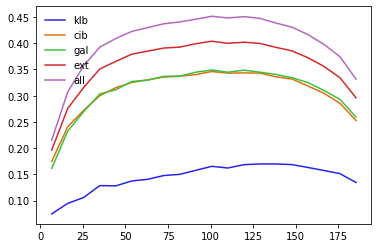

In [44]:
for wmass in dobj.ctypes:
    plot(mb.bc,np.mean(rho[wmass],axis=0),label=wmass)
legend()

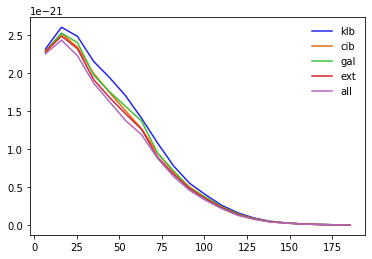

In [45]:
for wmass in dobj.ctypes:
    plot(mb.bc,np.std(Db[wmass],axis=0),label=wmass)
legend()